In [13]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt


# Typical Himalayan tunnel geology (mid-grade metamorphics)
# RMR (Rock Mass Rating): typically 30-65 for Himalayan tunnels
# UCS (Uniaxial Compressive Strength): 20-80 MPa for gneiss/schist
# RQD (Rock Quality Designation): 25-75% in jointed Himalayan rock


with pm.Model() as geo_prior_model:

    rmr = pm.Normal("rmr", mu=45, sigma=15)

    # Use truncated Normal to prevent negative values
    ucs = pm.TruncatedNormal("ucs", mu=50, sigma=20, lower=5, upper=200)

    # RQD: percentage, bounded 0-100, centered at 50%

    rqd = pm.Beta("rqd", alpha=5, beta=5)

    # Joint spacing: 0.1-2.0 meters, right-skewed
    joint_spacing = pm.Lognormal("joint_spacing", mu=np.log(0.3), sigma=0.7)


    prior_checks = pm.sample_prior_predictive(samples=2000, random_seed=42)

Sampling: [joint_spacing, rmr, rqd, ucs]


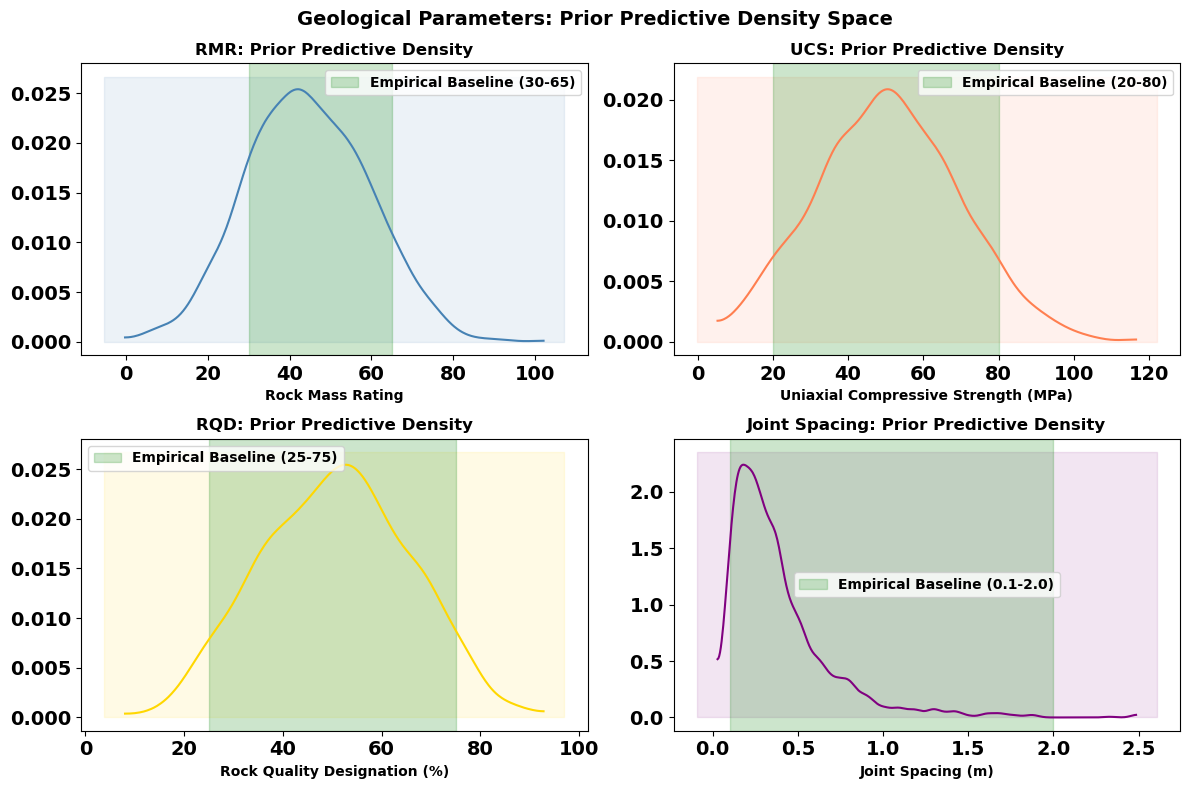

In [14]:
import arviz as az
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Continuous KDE replacing discretizing Histograms - Professional Labels
az.plot_kde(prior_checks.prior["rmr"].values.flatten(), ax=axes[0, 0], plot_kwargs={'color': 'steelblue'})
axes[0, 0].fill_between(axes[0, 0].get_xlim(), 0, axes[0, 0].get_ylim()[1], alpha=0.1, color='steelblue')
axes[0, 0].axvspan(30, 65, alpha=0.2, color='green', label='Empirical Baseline (30-65)')
axes[0, 0].set_title("RMR: Prior Predictive Density")
axes[0, 0].set_xlabel("Rock Mass Rating")
axes[0, 0].legend()

az.plot_kde(prior_checks.prior["ucs"].values.flatten(), ax=axes[0, 1], plot_kwargs={'color': 'coral'})
axes[0, 1].fill_between(axes[0, 1].get_xlim(), 0, axes[0, 1].get_ylim()[1], alpha=0.1, color='coral')
axes[0, 1].axvspan(20, 80, alpha=0.2, color='green', label='Empirical Baseline (20-80)')
axes[0, 1].set_title("UCS: Prior Predictive Density")
axes[0, 1].set_xlabel("Uniaxial Compressive Strength (MPa)")
axes[0, 1].legend()


az.plot_kde(prior_checks.prior["rqd"].values.flatten() * 100, ax=axes[1, 0], plot_kwargs={'color': 'gold'})
axes[1, 0].fill_between(axes[1, 0].get_xlim(), 0, axes[1, 0].get_ylim()[1], alpha=0.1, color='gold')
axes[1, 0].axvspan(25, 75, alpha=0.2, color='green', label='Empirical Baseline (25-75)')
axes[1, 0].set_title("RQD: Prior Predictive Density")
axes[1, 0].set_xlabel("Rock Quality Designation (%)")
axes[1, 0].legend()

az.plot_kde(prior_checks.prior["joint_spacing"].values.flatten(), ax=axes[1, 1], plot_kwargs={'color': 'purple'})
axes[1, 1].fill_between(axes[1, 1].get_xlim(), 0, axes[1, 1].get_ylim()[1], alpha=0.1, color='purple')
axes[1, 1].axvspan(0.1, 2.0, alpha=0.2, color='green', label='Empirical Baseline (0.1-2.0)')
axes[1, 1].set_title("Joint Spacing: Prior Predictive Density")
axes[1, 1].set_xlabel("Joint Spacing (m)")
axes[1, 1].legend()

plt.suptitle("Geological Parameters: Prior Predictive Density Space", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Sampling: [ucs]
Sampling: [ucs]


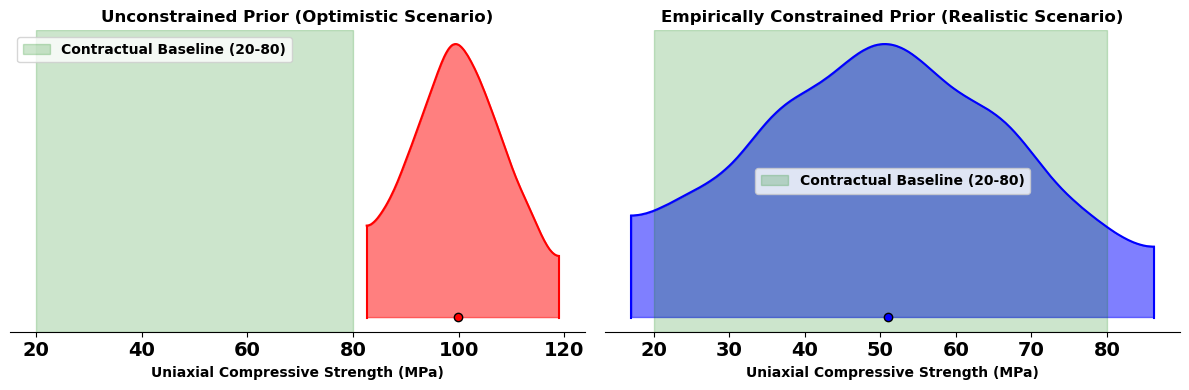

In [15]:
with pm.Model() as optimistic_model:
    ucs_optimistic = pm.Normal("ucs", mu=100, sigma=10)
    prior_opt = pm.sample_prior_predictive(samples=1000, random_seed=42)

with pm.Model() as realistic_model:
    ucs_realistic = pm.TruncatedNormal("ucs", mu=50, sigma=20, lower=5, upper=200)
    prior_real = pm.sample_prior_predictive(samples=1000, random_seed=42)

import arviz as az
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# The Orchestrator's Method: Continuous Density + Contractual Baselines
az.plot_density(prior_opt, group="prior", var_names=["ucs"], ax=axes[0], shade=0.5, colors=['red'])
axes[0].set_title("Unconstrained Prior (Optimistic Scenario)", fontweight='bold')
axes[0].set_xlabel("Uniaxial Compressive Strength (MPa)")
axes[0].axvspan(20, 80, alpha=0.2, color='green', label="Contractual Baseline (20-80)")
axes[0].legend()

az.plot_density(prior_real, group="prior", var_names=["ucs"], ax=axes[1], shade=0.5, colors=['blue'])
axes[1].set_title("Empirically Constrained Prior (Realistic Scenario)", fontweight='bold')
axes[1].set_xlabel("Uniaxial Compressive Strength (MPa)")
axes[1].axvspan(20, 80, alpha=0.2, color='green', label="Contractual Baseline (20-80)")
axes[1].legend()

plt.tight_layout()
plt.show()